In [2]:
import numpy as np

from power_demand_analysis import plotting
from power_demand_analysis.load import load_all

plotting.setup()
df = load_all()

[Text(0.5, 0, '時刻'), Text(0, 0.5, '平均需要(万kW)'), Text(0.5, 1.0, '時間帯別の平均電力需要')]

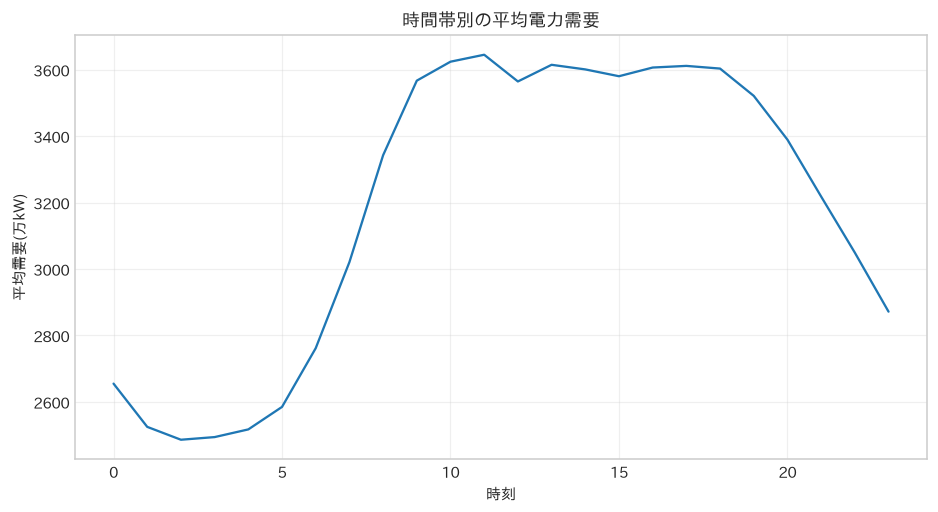

In [3]:
ax = df.groupby(df.index.hour)["demand_10mw"].mean().plot()
ax.set(xlabel="時刻", ylabel="平均需要(万kW)", title="時間帯別の平均電力需要")

[Text(0.5, 0, '時刻'),
 Text(0, 0.5, '平均需要 (万kW)'),
 Text(0.5, 1.0, '時間帯別の平均電力需要（平日 / 土日）')]

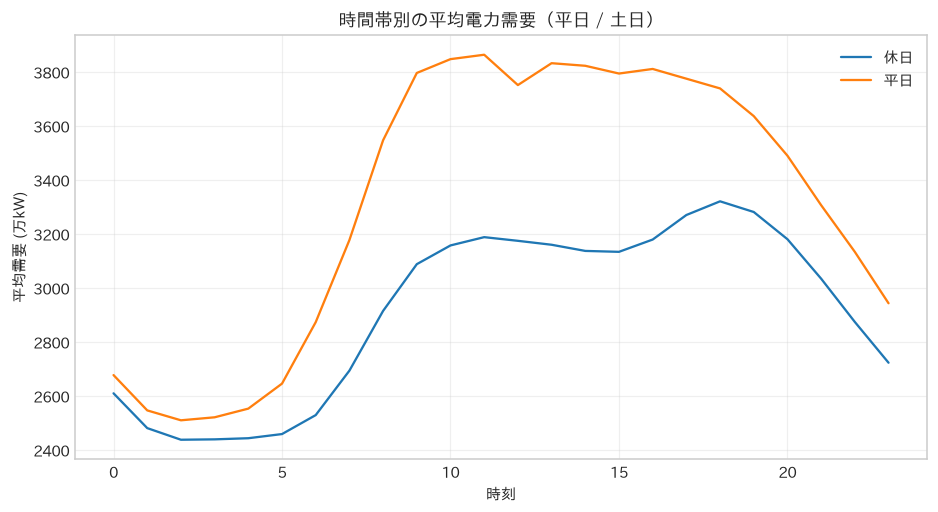

In [4]:
import jpholiday

holiday = np.array([jpholiday.is_holiday(d) for d in df.index.date])

s = np.where((df.index.dayofweek >= 5) | holiday, "休日", "平日")
ax = df.groupby([s, df.index.hour])["demand_10mw"].mean().unstack(0).plot()
ax.set(
    xlabel="時刻",
    ylabel="平均需要 (万kW)",
    title="時間帯別の平均電力需要（平日 / 土日）",
)

In [6]:
from power_demand_analysis.calendar import is_holiday

s = np.where(is_holiday(df.index), "休日", "平日")

[Text(0.5, 0, '月'), Text(0, 0.5, '平均需要(万kW)'), Text(0.5, 1.0, '月別の平均電力需要')]

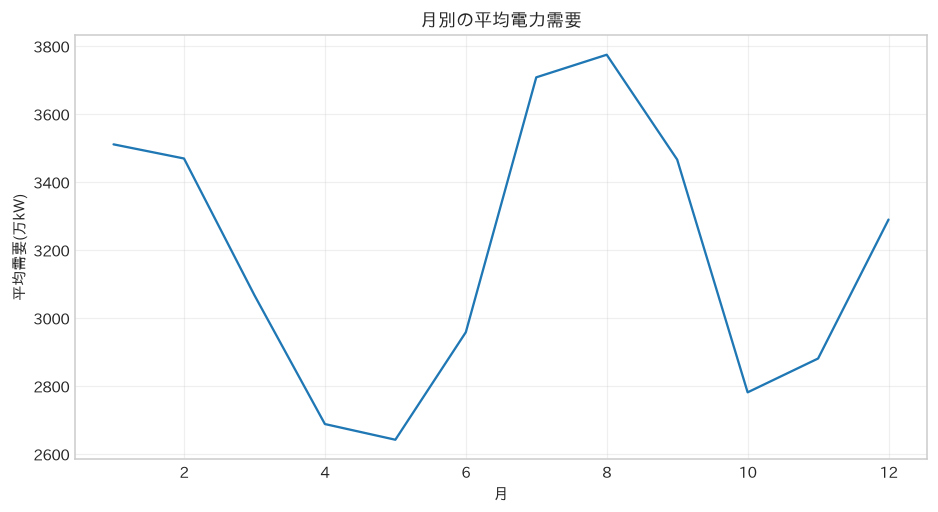

In [7]:
ax = df.groupby(df.index.month)["demand_10mw"].mean().plot()
ax.set(xlabel="月", ylabel="平均需要(万kW)", title="月別の平均電力需要")

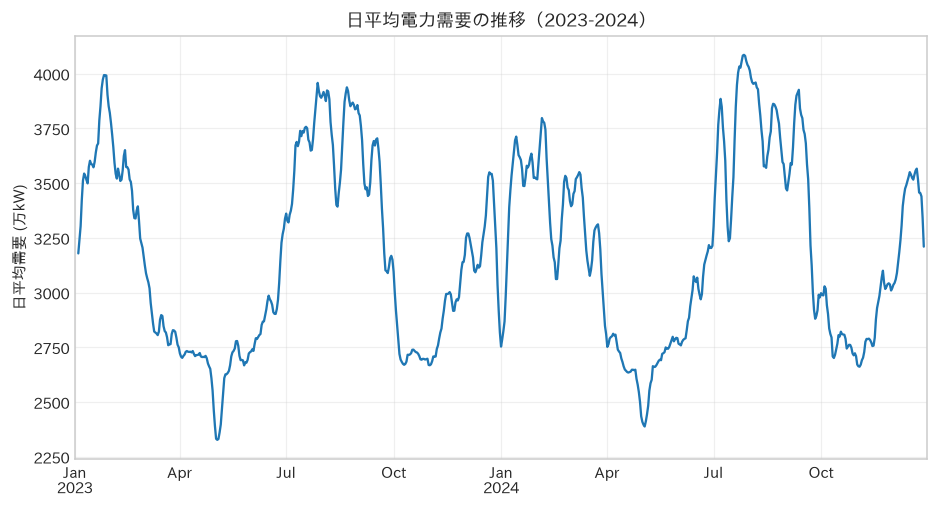

In [8]:
ax = df["demand_10mw"].resample("D").mean().rolling(window=7, center=True).mean().plot()
ax.set(
    xlabel="", ylabel="日平均需要 (万kW)", title="日平均電力需要の推移（2023-2024）"
);

<Axes: xlabel='temperature_2m', ylabel='demand_10mw'>

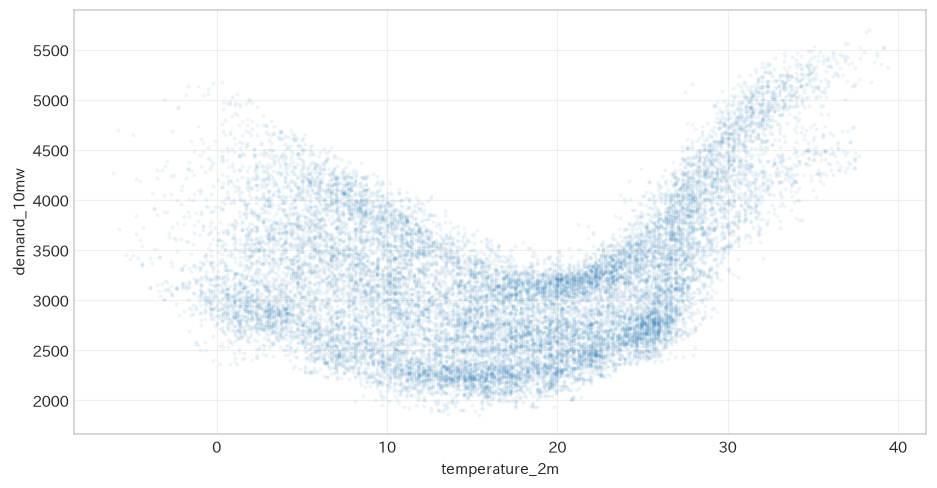

In [9]:
df.plot.scatter(x="temperature_2m", y="demand_10mw", alpha=0.05, s=3)

In [10]:
df[["temperature_2m", "demand_10mw"]].corr()

,temperature_2m,demand_10mw
temperature_2m,1.000000,0.238907
demand_10mw,0.238907,1.000000


In [14]:
df[df["temperature_2m"] < 16][["temperature_2m", "demand_10mw"]].corr()

,temperature_2m,demand_10mw
temperature_2m,1.000000,-0.399033
demand_10mw,-0.399033,1.000000


In [15]:
df[df["temperature_2m"] >= 16][["temperature_2m", "demand_10mw"]].corr()

,temperature_2m,demand_10mw
temperature_2m,1.00000,0.78629
demand_10mw,0.78629,1.00000


<Axes: xlabel='temperature_2m', ylabel='demand_10mw'>

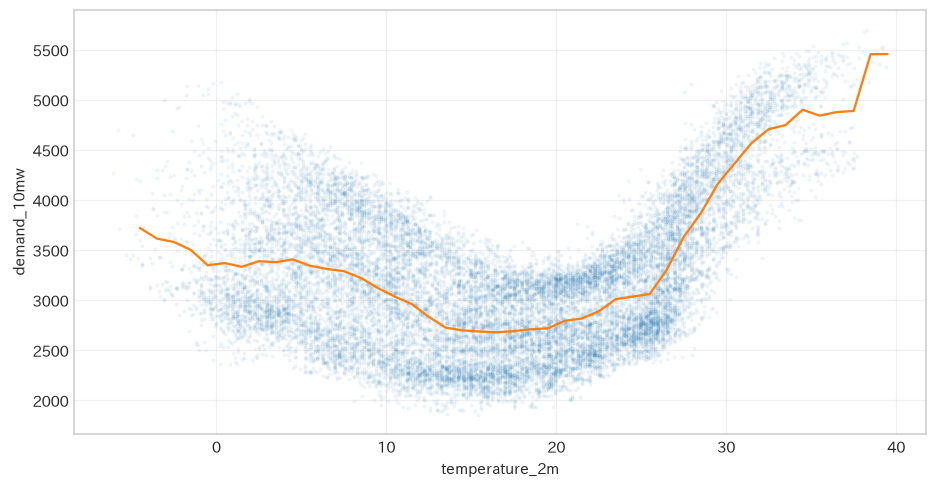

In [18]:
import pandas as pd

ax = df.plot.scatter(x="temperature_2m", y="demand_10mw", alpha=0.05, s=3)
bins = pd.cut(df["temperature_2m"], bins=range(-5, 41))
s = df.groupby(bins, observed=True)["demand_10mw"].mean()
s.index = [b.mid for b in s.index]

s.plot(ax=ax, color="C1")

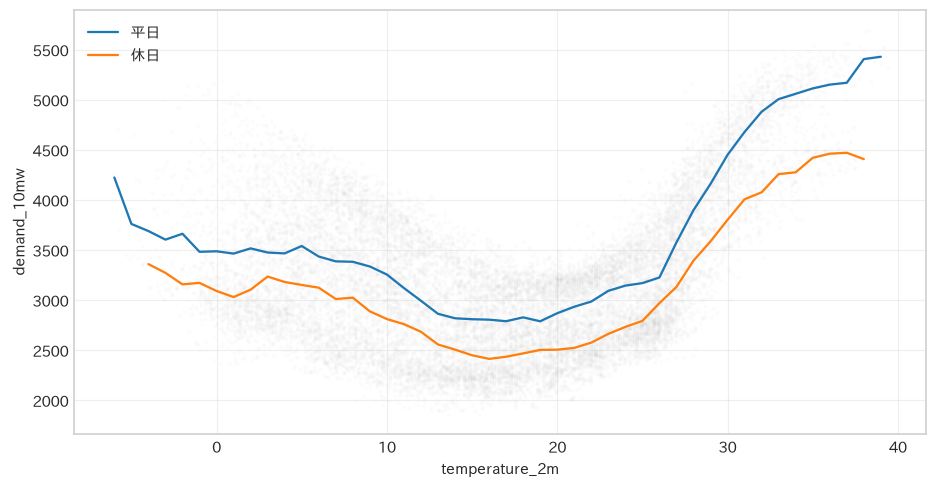

In [19]:
ax = df.plot.scatter(
    x="temperature_2m", y="demand_10mw", alpha=0.03, s=3, color="lightgray"
)
for label in ["平日", "休日"]:
    sub = df[np.where(is_holiday(df.index), "休日", "平日") == label]
    s = sub.groupby(sub["temperature_2m"].round())["demand_10mw"].mean()
    s.plot(ax=ax, label=label)

ax.legend()

<Axes: xlabel='temperature_2m'>

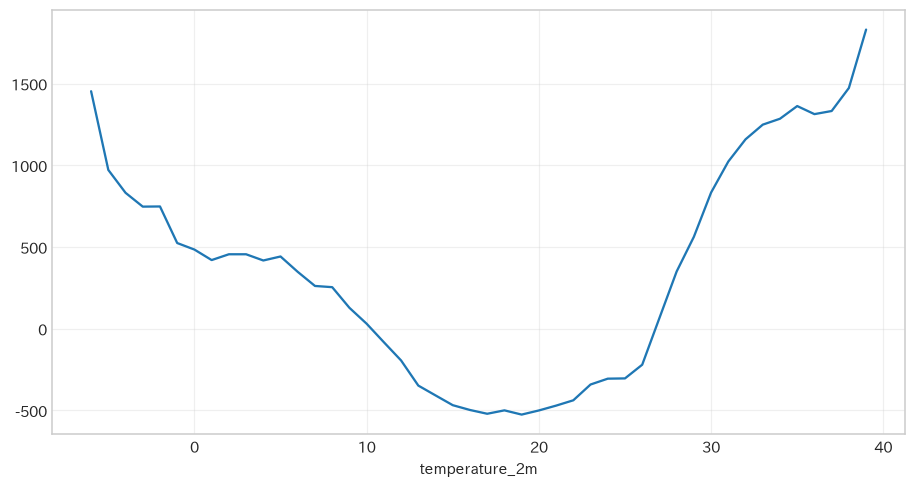

In [20]:
import numpy as np

x, y = df["temperature_2m"], df["demand_10mw"]

pred = np.polyval(np.polyfit(x, y, 1), x)
pd.Series(y - pred).groupby(x.round()).mean().plot()

<Axes: xlabel='temperature_2m'>

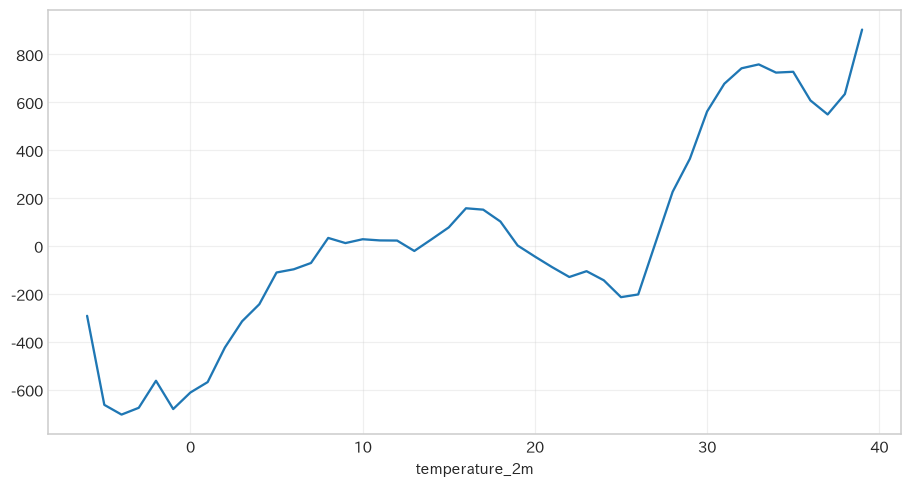

In [22]:
x2 = (df["temperature_2m"] - 16.5).abs()
pred2 = np.polyval(np.polyfit(x2, y, 1), x2)
pd.Series(y - pred2).groupby(df["temperature_2m"].round()).mean().plot()

<Axes: xlabel='temperature_2m'>

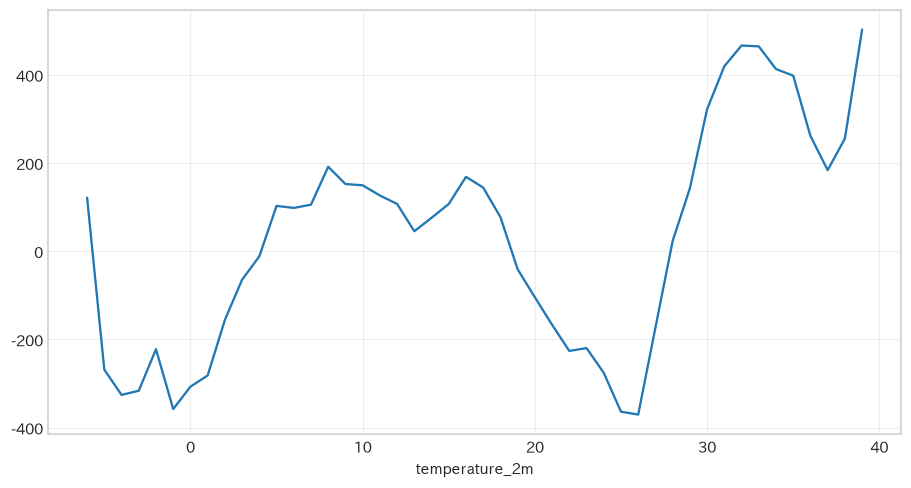

In [24]:
hdd = (16.5 - df["temperature_2m"]).clip(lower=0)  # 暖房側
cdd = (df["temperature_2m"] - 16.5).clip(lower=0)  # 冷房側

X = np.column_stack([hdd, cdd, np.ones(len(df))])
coef, *_ = np.linalg.lstsq(X, y, rcond=None)
pred3 = X @ coef
pd.Series(y - pred3).groupby(df["temperature_2m"].round()).mean().plot()